<a href="https://colab.research.google.com/github/tiniury-103/AdvancedDataAnalysis2526/blob/main/Q3_Code_onerun.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Num GPUs Available:  0
Random seed set to: 42
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TOTAL RECORDS FOR ANALYSIS: 50000

--- BLANK RECORDS PER VARIABLE ---
mths_since_last_record         47468
mths_since_last_major_derog    42880
mths_since_last_delinq         28126
tot_coll_amt                   14618
tot_cur_bal                    14618
emp_length                      1802
revol_util                        31

--- OUTLIERS DETECTED (Statistical) ---
                   Variable  Outlier Count     %
                       term           9359 18.72
                delinq_2yrs           7547 15.09
             inq_last_6mths           4151  8.30
                    pub_rec           2532  5.06
               tot_coll_amt           2319  4.64
                 annual_inc           2289  4.58
                  revol_bal           2066  4.13
                installment           1278  2.56
              

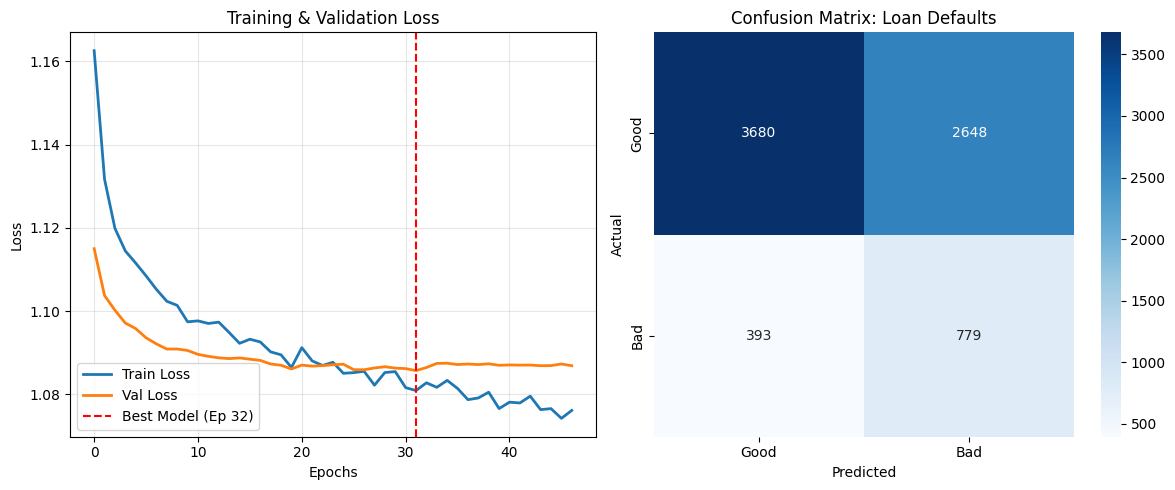

In [6]:
import pandas as pd
import numpy as np
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import seaborn as sns
import matplotlib.pyplot as plt
import random
import os

# Check for GPU availability
print("Num GPUs Available: ", torch.cuda.device_count())

# Device Setup
# Must define 'device' before moving any models or tensors
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Fixate randomness
def set_seed(seed=42):
    """
    Sets the seed for reproducibility across Python, NumPy, and PyTorch.
    """
    # 1. Base Python
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

    # 2. NumPy
    np.random.seed(seed)

    # 3. PyTorch (CPU)
    torch.manual_seed(seed)

    # 4. PyTorch (GPU/CUDA)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed) # For multi-GPU setups

    # 5. Deterministic algorithms (Note: this may slow down training slightly)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    print(f"Random seed set to: {seed}")

# Call the function
set_seed(42)


# =================================================================================================================================
# 1. Load Data & Define Target
# =================================================================================================================================
# Use this code if data is stored locally
#df = pd.read_csv('early_2012_2013_loan_sample_with_outcome.csv')

# Use this code if data is in Google Drive
# Mount Google Drive in Colab
from google.colab import drive
drive.mount('/content/drive')
file_path = "/content/drive/MyDrive/Colab Notebooks/ADA/early_2012_2013_loan_sample_with_outcome.csv"
df = pd.read_csv(file_path, low_memory=False)

# Define Target: 1 = Default/Bad Loan, 0 = Repaid
y = df['loan_is_bad'].astype(int)


# =================================================================================================================================
# 2. Justified Feature Selection (using 24 from 57 vars)
# =================================================================================================================================
# To properly evaluate loan policies at the time of origination[cite: 7],
# the model must only use data available on the exact day the borrower applies.
# We explicitly EXCLUDE the following variables to ensure model validity:
#
# 1. DATA LEAKAGE (Future Events):
#    - 'total_pymnt', 'recoveries', 'collection_recovery_fee', 'out_prncp',
#      'total_rec_prncp', 'total_rec_int', 'last_pymnt_d', 'next_pymnt_d'
#    - REASON: These metrics describe what happens AFTER the loan is approved.
#      If included, the neural network will "cheat" by looking into the future,
#      rendering the prototype invalid for real-world decision-making.
#
# 2. TARGET LEAKAGE (The Answer Key):
#    - 'loan_status'
#    - REASON: This column ("Fully Paid", "Charged Off") is the exact outcome
#      we are trying to predict ('loan_is_bad'). Including it gives the model
#      the answer key.
#
# 3. ADMINISTRATIVE / NOISE:
#    - 'id', 'member_id', 'policy_code'
#    - REASON: IDs are random database keys with zero predictive power. The
#      policy_code is identical for all rows in this sample.
#
# 4. UNSTRUCTURED TEXT:
#    - 'desc', 'title'
#    - REASON: Free-form text written by the borrower requires complex Natural
#      Language Processing (NLP). For a fast prototype[cite: 15], this is
#      computationally expensive and largely redundant with the categorical
#      'purpose' column.
#
# INCLUSIONS (The Origination Features):
features_to_keep = [
    # Loan Characteristics
    'loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'purpose',
    # Borrower Demographics & Income
    'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'dti',
    # Credit Bureau History
    'delinq_2yrs', 'inq_last_6mths', 'mths_since_last_delinq',
    'mths_since_last_record', 'mths_since_last_major_derog',
    'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
    'tot_cur_bal', 'tot_coll_amt'
]
X = df[features_to_keep].copy()

# =================================================================================================================================
# 3. Data Preparation (Cleaning)
# =================================================================================================================================
# ==========================================
# 3.1. Dataset Scale
# ==========================================
total_records = len(X)
print(f"TOTAL RECORDS FOR ANALYSIS: {total_records}\n")

# ==========================================
# 3.2. Diagnostic: Count Blanks and Outliers
# ==========================================
# 2a. Count Blanks (Missing values)
blanks = X.isnull().sum()
blanks = blanks[blanks > 0].sort_values(ascending=False)

print("--- BLANK RECORDS PER VARIABLE ---")
if not blanks.empty:
    print(blanks.to_string())
else:
    print("No blanks found in selected features.")

# 2b. Count Outliers (using 1.5 * IQR method)
print("\n--- OUTLIERS DETECTED (Statistical) ---")
numeric_cols = X.select_dtypes(include=[np.number]).columns
outlier_list = []

for col in numeric_cols:
    series = X[col].dropna()
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    count = ((series < lower_bound) | (series > upper_bound)).sum()
    if count > 0:
        outlier_list.append({'Variable': col, 'Outlier Count': count, '%': round((count/total_records)*100, 2)})

outlier_summary = pd.DataFrame(outlier_list).sort_values(by='%', ascending=False)
print(outlier_summary.to_string(index=False))

# ==========================================
# 3.3. Handling Anomalies (Business & Statistical Logic)
# ==========================================
print("\n--- HANDLING ANOMALIES ---")

# A. Logical Imputation for 'Never' Events
# These are blank because the event never happened, not because data is missing.
never_happened_cols = ['mths_since_last_delinq', 'mths_since_last_record', 'mths_since_last_major_derog']
for col in never_happened_cols:
    X[col] = X[col].fillna(999) # Placeholder for 'Never'
print("1. Logical Imputation: Blanks in 'mths_since_last...' filled with 999 (Never).")

# B. Zero-Filling for Credit Balances
# Blanks here logically imply no current balance or collections ever owed.
zero_fill_cols = ['tot_cur_bal', 'tot_coll_amt']
for col in zero_fill_cols:
    X[col] = X[col].fillna(0)
print("2. Logical Imputation: Blanks in 'tot_cur_bal' and 'tot_coll_amt' filled with 0.")

# C. Handling Financial Outliers (Capping/Winsorizing)
# To stabilize the Deep Learning model, we cap extreme wealth at the 99th percentile.
# This prevents extreme outliers (like multimillionaires) from skewing the model.
cap_cols = ['annual_inc', 'revol_bal', 'tot_cur_bal', 'total_acc']
for col in cap_cols:
    limit = X[col].quantile(0.99)
    X[col] = np.where(X[col] > limit, limit, X[col])
print("3. Outlier Handling: Capped extreme financial metrics at the 99th percentile.")

# D. Administrative Fixes
if X['revol_util'].dtype == object:
    X['revol_util'] = X['revol_util'].str.rstrip('%').astype(float) / 100.0
print("4. Format Fix: Converted 'revol_util' percentage strings to floats.")

from torch.utils.data import DataLoader, TensorDataset

# =================================================================================================================================
# 4. Data Splitting & Automated Preprocessing
# =================================================================================================================================
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

# 70% Train, 15% Validation, 15% Test split with Stratification
# Stratify ensures the % of "Bad Loans" is the same in all three sets.
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp)

# Pipeline for statistical imputation (Median for emp_length and revol_util)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Processed data
X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc = preprocessor.transform(X_val)
X_test_proc = preprocessor.transform(X_test)

# Convert to Tensors
X_train_t = torch.FloatTensor(X_train_proc)
y_train_t = torch.FloatTensor(y_train.values).view(-1, 1)
X_val_t = torch.FloatTensor(X_val_proc)
y_val_t = torch.FloatTensor(y_val.values).view(-1, 1)
X_test_t = torch.FloatTensor(X_test_proc)
y_test_t = torch.FloatTensor(y_test.values).view(-1, 1)

# Create DataLoaders for Mini-Batch training (64 records per step)
batch_size = 64
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=batch_size, shuffle=False)



# =================================================================================================================================
# 5. Advanced Model Architecture & Loss
# =================================================================================================================================

# Calculate pos_weight and move it to the device
num_negatives = (y_train == 0).sum()
num_positives = (y_train == 1).sum()
pos_weight_val = torch.FloatTensor([num_negatives / num_positives]).to(device)

class LoanDefaultPredictorDNN(nn.Module):
    def __init__(self, input_dim, num_classes=1, dropout_rate=0.3):
        super(LoanDefaultPredictorDNN, self).__init__()

        self.network = nn.Sequential(
            # Layer 1: Input to Hidden
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            # Layer 2: Hidden to Hidden
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            # Output Layer: Results in raw 'logits' for BCEWithLogitsLoss
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        return self.network(x)

# Instantiate and move to device
model = LoanDefaultPredictorDNN(input_dim=X_train_proc.shape[1]).to(device)

# BCEWithLogitsLoss for binary classification
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_val)

# AdamW adds weight decay directly to the weight update rule for better regularization
optimizer = optim.AdamW(model.parameters(), lr=0.0001, weight_decay=1e-4)

# Learning Rate Scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# Create Test Loader
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=64, shuffle=False)



# =================================================================================================================================
# 6. Optimized Training Engine
# =================================================================================================================================
epochs = 100
patience = 15  # Early stopping patience
best_val_loss = float('inf')
epochs_no_improve = 0
early_stop = False

train_losses, val_losses = [], []

print("\n--- EPOCH PERFORMANCE ---")
for epoch in range(epochs):
    if early_stop:
        print(f"Early stopping triggered at epoch {epoch}")
        break

    # --- Training Phase ---
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        # Move batch data to device
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    epoch_train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    # --- Validation Phase ---
    model.eval()
    val_loss_sum = 0.0
    with torch.no_grad():
        for v_inputs, v_labels in val_loader:
            v_inputs, v_labels = v_inputs.to(device), v_labels.to(device)
            v_outputs = model(v_inputs)
            v_loss = criterion(v_outputs, v_labels)
            val_loss_sum += v_loss.item() * v_inputs.size(0)

    epoch_val_loss = val_loss_sum / len(val_loader.dataset)
    val_losses.append(epoch_val_loss)

    # Update Learning Rate Scheduler based on validation loss
    scheduler.step(epoch_val_loss)

    # --- Early Stopping & Saving Best Model ---
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), 'best_loan_model.pth')
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            early_stop = True

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:03d}/{epochs} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")



# =================================================================================================================================
# 7. FINAL EVALUATION & PLOTTING
# =================================================================================================================================

# Load the best saved weights
model.load_state_dict(torch.load('best_loan_model.pth'))
model.to(device)
model.eval()

all_preds = []
all_labels = []
test_loss = 0.0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        # Forward pass
        logits = model(inputs)
        loss = criterion(logits, labels)
        test_loss += loss.item() * inputs.size(0)

        # Convert logits to binary predictions (0 or 1)
        # We use sigmoid for probability, then 0.5 threshold
        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).float()

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Flatten lists for metric calculations
all_preds = np.array(all_preds).flatten()
all_labels = np.array(all_labels).flatten()

# ==========================================
# 7.1 CONFUSION MATRIX
# ==========================================
avg_test_loss = test_loss / len(test_loader.dataset)
print(f"\nFinal Test Loss: {avg_test_loss:.4f}")
print("\n--- Classification Report ---")
print(classification_report(all_labels, all_preds, target_names=['Good Loan', 'Bad Loan']))

# ==========================================
# 7.2 DETAILED ERROR METRICS (FPR & FNR)
# ==========================================

# Extract components from confusion matrix
# cm[0,0] = TN, cm[0,1] = FP, cm[1,0] = FN, cm[1,1] = TP
tn, fp, fn, tp = cm.ravel()

# Calculate Rates
fpr = fp / (fp + tn)  # False Positive Rate
fnr = fn / (fn + tp)  # False Negative Rate
precision = tp / (tp + fp)
recall = tp / (tp + fn) # Same as Sensitivity / 1 - FNR

print(f"--- Advanced Lending Metrics ---")
print(f"False Positive Rate (FPR): {fpr:.2%}")
print(f"False Negative Rate (FNR): {fnr:.2%}")
print(f"---------------------------------")

# Interpretation Logic
print("\n--- Business Interpretation ---")
print(f"1. FPR ({fpr:.2%}): This is the 'Opportunity Cost'.")
print(f"   - Out of all GOOD loans, the model wrongly rejected {fpr:.2%}.")
print(f"   - High FPR means you are being too strict and losing safe interest income.")

print(f"\n2. FNR ({fnr:.2%}): This is the 'Default Risk'.")
print(f"   - Out of all BAD loans, the model wrongly approved {fnr:.2%}.")
print(f"   - High FNR is dangerous; it means the bank is losing principal capital to defaults.")

# ==========================================
# 7.3 PLOTTING
# ==========================================
# --- Plot 1: Learning Curves ---
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', color='#1f77b4', lw=2)
plt.plot(val_losses, label='Val Loss', color='#ff7f0e', lw=2)
# Mark the best epoch
best_epoch = len(train_losses) - epochs_no_improve
plt.axvline(x=best_epoch - 1, color='red', linestyle='--', label=f'Best Model (Ep {best_epoch})')
plt.title('Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)

# --- Plot 2: Confusion Matrix ---
plt.subplot(1, 2, 2)
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Good', 'Bad'], yticklabels=['Good', 'Bad'])
plt.title('Confusion Matrix: Loan Defaults')
plt.ylabel('Actual')
plt.xlabel('Predicted')

plt.tight_layout()
plt.show()